<a href="https://colab.research.google.com/github/diveshf20/Exploratory-Data-Analysis-EDA-/blob/main/Titanic_EDA_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:

# Set seaborn style
sns.set(style="whitegrid")


In [6]:


# Load CSV files from the current directory (no 'titanic/' prefix)
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")
gender_df = pd.read_csv("gender_submission.csv")


In [7]:

# Quick info
print("\n Train Data:")
print(train_df.info())
print(train_df.head())


 Train Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

        

In [8]:
print("\n Test Data:")
print(test_df.info())
print(test_df.head())

print("\n Gender Submission (Survival Predictions):")
print(gender_df.info())
print(gender_df.head())


 Test Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    object 
 3   Sex          418 non-null    object 
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    object 
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     object 
 10  Embarked     418 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 36.1+ KB
None
   PassengerId  Pclass                                          Name     Sex  \
0          892       3                              Kelly, Mr. James    male   
1          893       3              Wilkes, Mrs. James (Ellen Needs)  female   
2          894       2      

In [9]:

# Missing values
print("\n Missing Values:")
print(train_df.isnull().sum())

# Basic stats
print("\n Descriptive Stats:")
print(train_df.describe())



 Missing Values:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

 Descriptive Stats:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.20

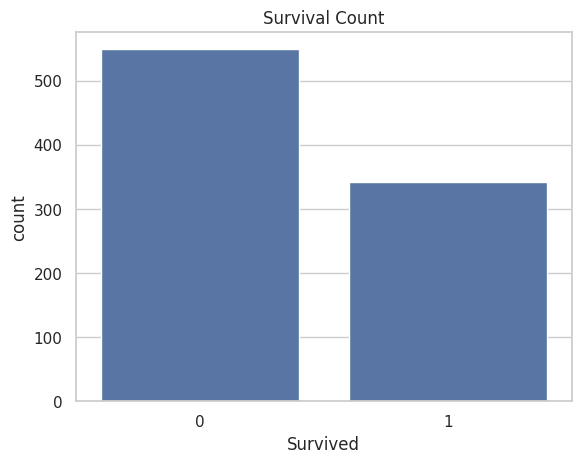

In [10]:

# Survival count
sns.countplot(x='Survived', data=train_df)
plt.title("Survival Count")
plt.show()


**Survival Count**
•	Around 38% passengers survived.
•	Data is slightly imbalanced with more non-survivors.


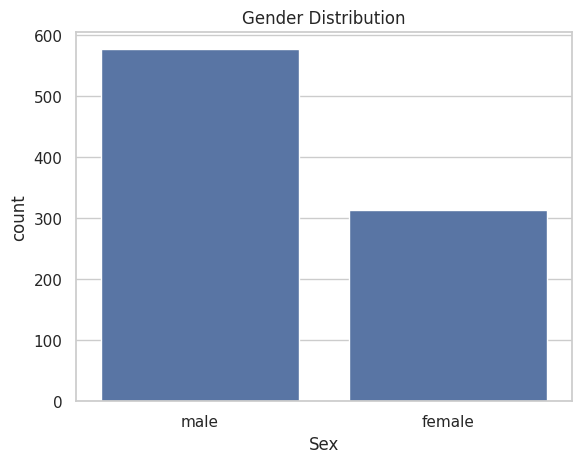

In [11]:

# Gender distribution
sns.countplot(x='Sex', data=train_df)
plt.title("Gender Distribution")
plt.show()


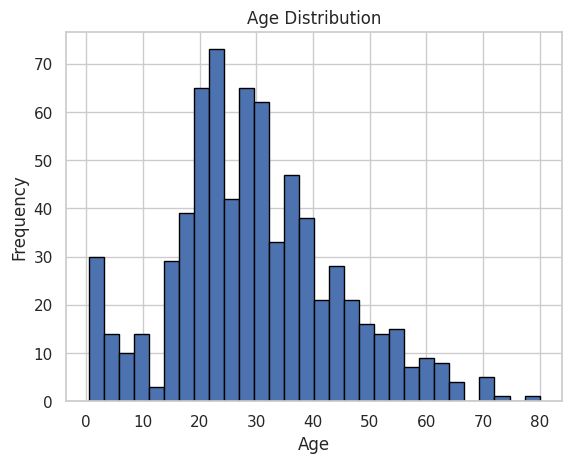

In [12]:

# Age distribution
train_df['Age'].plot.hist(bins=30, edgecolor='black')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

**Age Distribution**
•	The peak age group is around 25–30 years.
•	The data shows a decline in frequency as the age increases beyond 40.


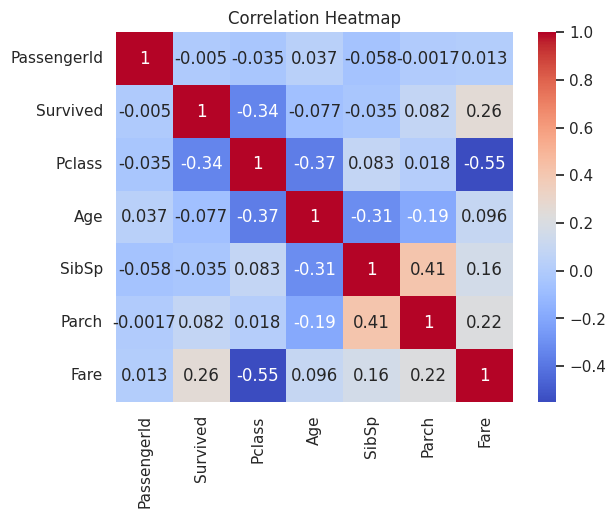

In [13]:
# Correlation heatmap
sns.heatmap(train_df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

 **Correlation Heatmap**
•	The heatmap shows the pairwise correlation between numerical variables in the Titanic dataset using Pearson correlation coefficients (values range from -1 to 1).
•	Age has weak/no correlation with survival but may still provide useful nonlinear patterns when analysed by groups (like children vs adults).


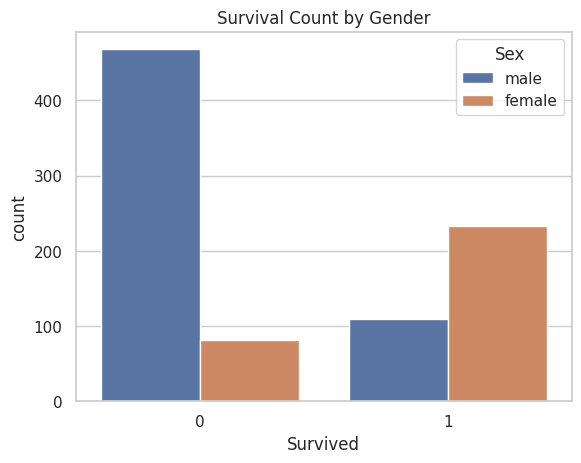

In [14]:
# gender vs survival
sns.countplot(x='Survived', hue='Sex', data=train_df)
plt.title("Survival Count by Gender")
plt.show()

**Survival by Gender**
•	Females had a significantly higher survival rate.
•	“Women and children first” policy may have influenced this.


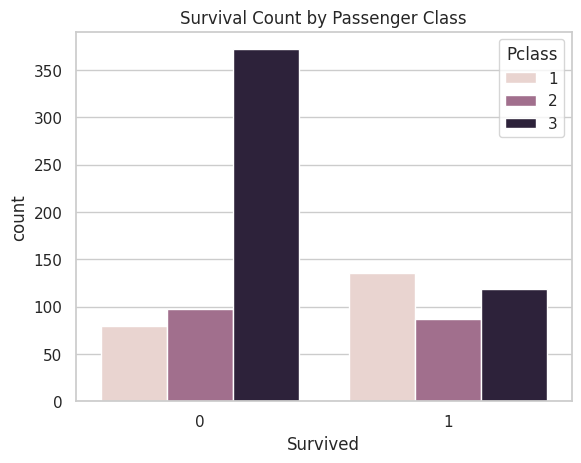

In [15]:

# class vs survival
sns.countplot(x='Survived', hue='Pclass', data=train_df)
plt.title("Survival Count by Passenger Class")
plt.show()

**Survival by Passenger Class**
•	1st class passengers had much better survival chances.
•	3rd class had the highest death rate.


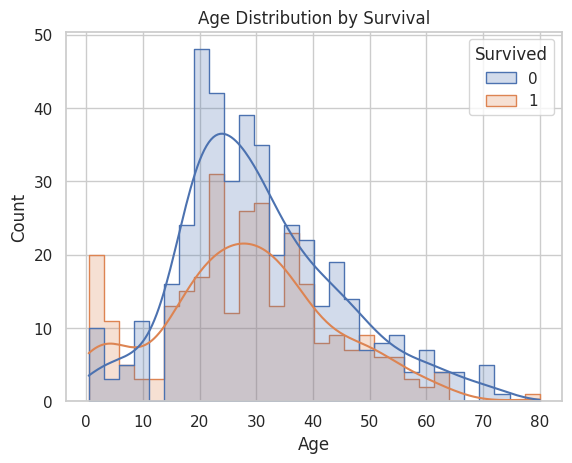

In [16]:

#age distribution by survival
sns.histplot(data=train_df, x="Age", hue="Survived", bins=30, kde=True, element="step")
plt.title("Age Distribution by Survival")
plt.show()

**Age Distribution by Survival**
•	Children (under 10) had a better survival rate.
•	Many deaths occurred in 20–40 age range.


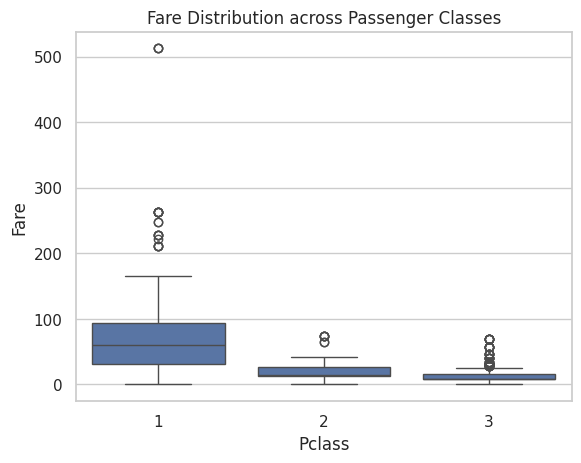

In [17]:

#Boxplot: Fare vs Pclass
sns.boxplot(x='Pclass', y='Fare', data=train_df)
plt.title("Fare Distribution across Passenger Classes")
plt.show()


 **Fare vs Pclass**
•	1st class fares were the highest.
•	Some passengers paid very high fares (outliers).


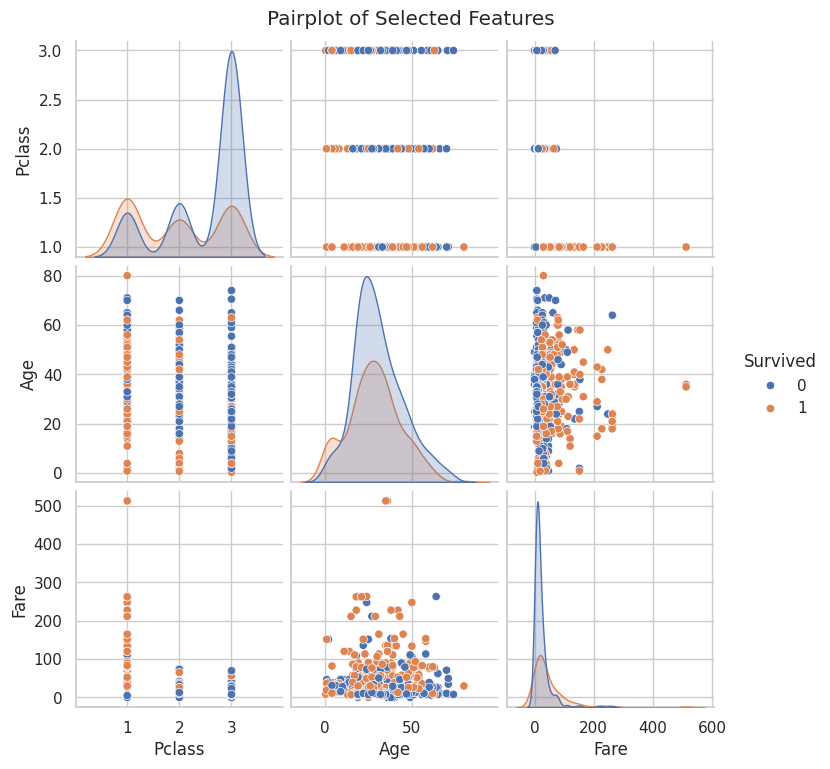

In [18]:

#Pairplot of numeric features
sns.pairplot(train_df[["Survived", "Pclass", "Age", "Fare"]], hue='Survived')
plt.suptitle("Pairplot of Selected Features", y=1.02)
plt.show()


**Pairplot of Selected Features**
•	Fare and Pclass show strong patterns with survival.
•	Good features for prediction modeling.
